## Paquid dataset application using the `jmstate` package

In [1]:
%pip install -q jmstate==0.17.2 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch import nn

In [3]:
torch.manual_seed(42)

paquid = pd.read_csv("../data/paquid.csv")

# Convert all numeric columns to float32
numeric_cols = paquid.select_dtypes(include="number").columns
paquid[numeric_cols] = paquid[numeric_cols].astype("float32")

In [4]:
groups = paquid.groupby("ID")
ids = range(1, 501)
pad = nn.utils.rnn.pad_sequence

trajectories, c, t, y, x = [], [], [], [], []

for i in ids:
    g = groups.get_group(i)

    s = g.groupby("HIER")["age"].min().reindex(range(4)).dropna()
    s = s[s >= s.cummax()]
    trajectories.append([((float(a) - 65) / 10, int(k)) for k, a in s.items()])

    c.append((g["age"].max() - 65) / 10)
    t.append((torch.tensor(g["age"].values) - 65) / 10)
    y.append(torch.tensor(g["MMSE"].values / 30))
    x.append(torch.tensor(g[["CEP", "male"]].iloc[0].values))

c = torch.tensor(c)[:, None]
t = pad(t, batch_first=True, padding_value=torch.nan)
y = pad(y, batch_first=True, padding_value=torch.nan)[..., None]
x = torch.stack(x)

In [5]:
from jmstate.utils import build_buckets

buckets = build_buckets(trajectories)
print({k: v.idxs.numel() for k, v in buckets.items()})

{(0, 1): 85, (0, 2): 44, (0, 3): 11, (1, 2): 135, (1, 3): 15, (2, 3): 86}


In [6]:
from jmstate.functions.base_hazards import Weibull
from jmstate.types import ModelData, ModelDesign, ModelParameters, PrecisionParameters


def sigmoid(t: torch.Tensor, indiv_params: torch.Tensor):
    scale, offset, slope = indiv_params.chunk(3, dim=-1)
    return (scale * torch.sigmoid((offset - t) / slope)).unsqueeze(-1)


def f(fixed: torch.Tensor, x: torch.Tensor, b: torch.Tensor):
    x_aug = torch.cat([torch.ones(x.shape[0], 1), x], dim=-1)
    fixed = fixed.reshape(3, 3)
    indiv_params = x_aug @ fixed.T + b
    indiv_params[..., -1] = indiv_params[..., -1].exp()
    return indiv_params


def init_params():
    shared_x_coef = nn.Parameter(torch.zeros(2))
    return ModelParameters(
        torch.zeros(9).index_put((torch.tensor(0),), torch.tensor(1.0)),
        PrecisionParameters.from_covariance(torch.eye(3), "full"),
        PrecisionParameters.from_covariance(torch.eye(1), "spherical"),
        {key: Weibull(1.0, 1.0) for key in buckets},
        {key: torch.zeros(1) for key in buckets},
        dict.fromkeys(buckets, shared_x_coef),
    )

# Define model design and data
design = ModelDesign(f, sigmoid, dict.fromkeys(buckets, sigmoid))
data = ModelData(x, t, y, trajectories, c)

In [7]:
from jmstate import MultiStateJointModel

torch.manual_seed(42)
params = init_params()
optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
model = MultiStateJointModel(
    design, params, optimizer, max_iter=5000, window_size=500
).fit(data)

Fitting joint model:  59%|█████▉    | 2957/5000 [02:46<01:55, 17.75it/s]


Computing FIM and Model Selection Criteria: 100%|██████████| 100/100 [00:11<00:00,  8.66it/s]


╭──────────────────────────────────────────── Model Summary ─────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓ │
│ ┃ Parameter name                  ┃ Value  ┃ Standard Error ┃ z-value ┃ p-value ┃ Significance level ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩ │
│ │ fixed_effects[0]                │ 1.201  │     0.035      │ 33.889  │  0.000  │        ***         │ │
│ │ fixed_effects[1]                │ 0.221  │     0.042      │  5.298  │  0.000  │        ***         │ │
│ │ fixed_effects[2]                │ 0.155  │     0.041      │  3.751  │  0.000  │        ***         │ │
│ │ fixed_effects[3]                │ 3.321  │     0.076      │ 43.591  │  0.000  │        ***         │ │
│ │ fixed_effects[4]                │ 0.181  │     0.094      │  1.920  │  0.055  │         .          │ │
│ │ fixed_effects[5]                │ 0.568  │     0.119      │  4.773  │  0.000  │        ***         │ │
│ │ fixed_effects[6]                │ 0.636  │     0.188      │  3.382  │  0.001  │        ***         │ │
│ │ fixed_effects[7]                │ 0.663  │     0.229      │  2.896  │  0.004  │         **         │ │
│ │ fixed_effects[8]                │ 1.168  │     0.233      │  5.012  │  0.000  │        ***         │ │
│ │ random_prec.flat[0]             │ 2.537  │     0.079      │ 32.260  │  0.000  │        ***         │ │
│ │ random_prec.flat[1]             │ -0.032 │     0.321      │  0.101  │  0.920  │                    │ │
│ │ random_prec.flat[2]             │ 0.644  │     0.086      │  7.508  │  0.000  │        ***         │ │
│ │ random_prec.flat[3]             │ -1.909 │     0.134      │ 14.248  │  0.000  │        ***         │ │
│ │ random_prec.flat[4]             │ -0.752 │     0.100      │  7.486  │  0.000  │        ***         │ │
│ │ random_prec.flat[5]             │ -0.690 │     0.065      │ 10.594  │  0.000  │        ***         │ │
│ │ noise_prec.flat[0]              │ 3.023  │     0.008      │ 396.463 │  0.000  │        ***         │ │
│ │ base_hazards.(0, 1).log_lmda[0] │ -1.174 │     1.090      │  1.077  │  0.281  │                    │ │
│ │ base_hazards.(0, 1).log_k[0]    │ 0.269  │     0.125      │  2.145  │  0.032  │         *          │ │
│ │ base_hazards.(0, 2).log_lmda[0] │ 1.160  │     0.585      │  1.982  │  0.047  │         *          │ │
│ │ base_hazards.(0, 2).log_k[0]    │ 0.648  │     0.142      │  4.557  │  0.000  │        ***         │ │
│ │ base_hazards.(0, 3).log_lmda[0] │ 1.663  │     0.769      │  2.164  │  0.030  │         *          │ │
│ │ base_hazards.(0, 3).log_k[0]    │ 0.876  │     0.352      │  2.486  │  0.013  │         *          │ │
│ │ base_hazards.(1, 2).log_lmda[0] │ 1.260  │     0.519      │  2.428  │  0.015  │         *          │ │
│ │ base_hazards.(1, 2).log_k[0]    │ 0.434  │     0.097      │  4.472  │  0.000  │        ***         │ │
│ │ base_hazards.(1, 3).log_lmda[0] │ 2.744  │     0.926      │  2.964  │  0.003  │         **         │ │
│ │ base_hazards.(1, 3).log_k[0]    │ 0.520  │     0.283      │  1.836  │  0.066  │         .          │ │
│ │ base_hazards.(2, 3).log_lmda[0] │ 2.239  │     0.346      │  6.478  │  0.000  │        ***         │ │
│ │ base_hazards.(2, 3).log_k[0]    │ 0.509  │     0.107      │  4.777  │  0.000  │        ***         │ │
│ │ link_coefs.(0, 1)[0]            │ 1.254  │     1.614      │  0.776  │  0.437  │                    │ │
│ │ link_coefs.(0, 2)[0]            │ -3.844 │     1.281      │  3.000  │  0.003  │         **         │ │
│ │ link_coefs.(0, 3)[0]            │ -8.487 │     1.362      │  6.231  │  0.000  │        ***         │ │
│ │ link_coefs.(1, 2)[0]            │ -2.167 │     0.898      │  2.413  │  0.016  │         *          │ │
│ │ link_coefs.(1, 3)[0]            │ -8.393 │     0.957      │  8.772  │  0.000  │        ***         │ │
│ │ link_coefs.(2, 3)[0]            │ -5.

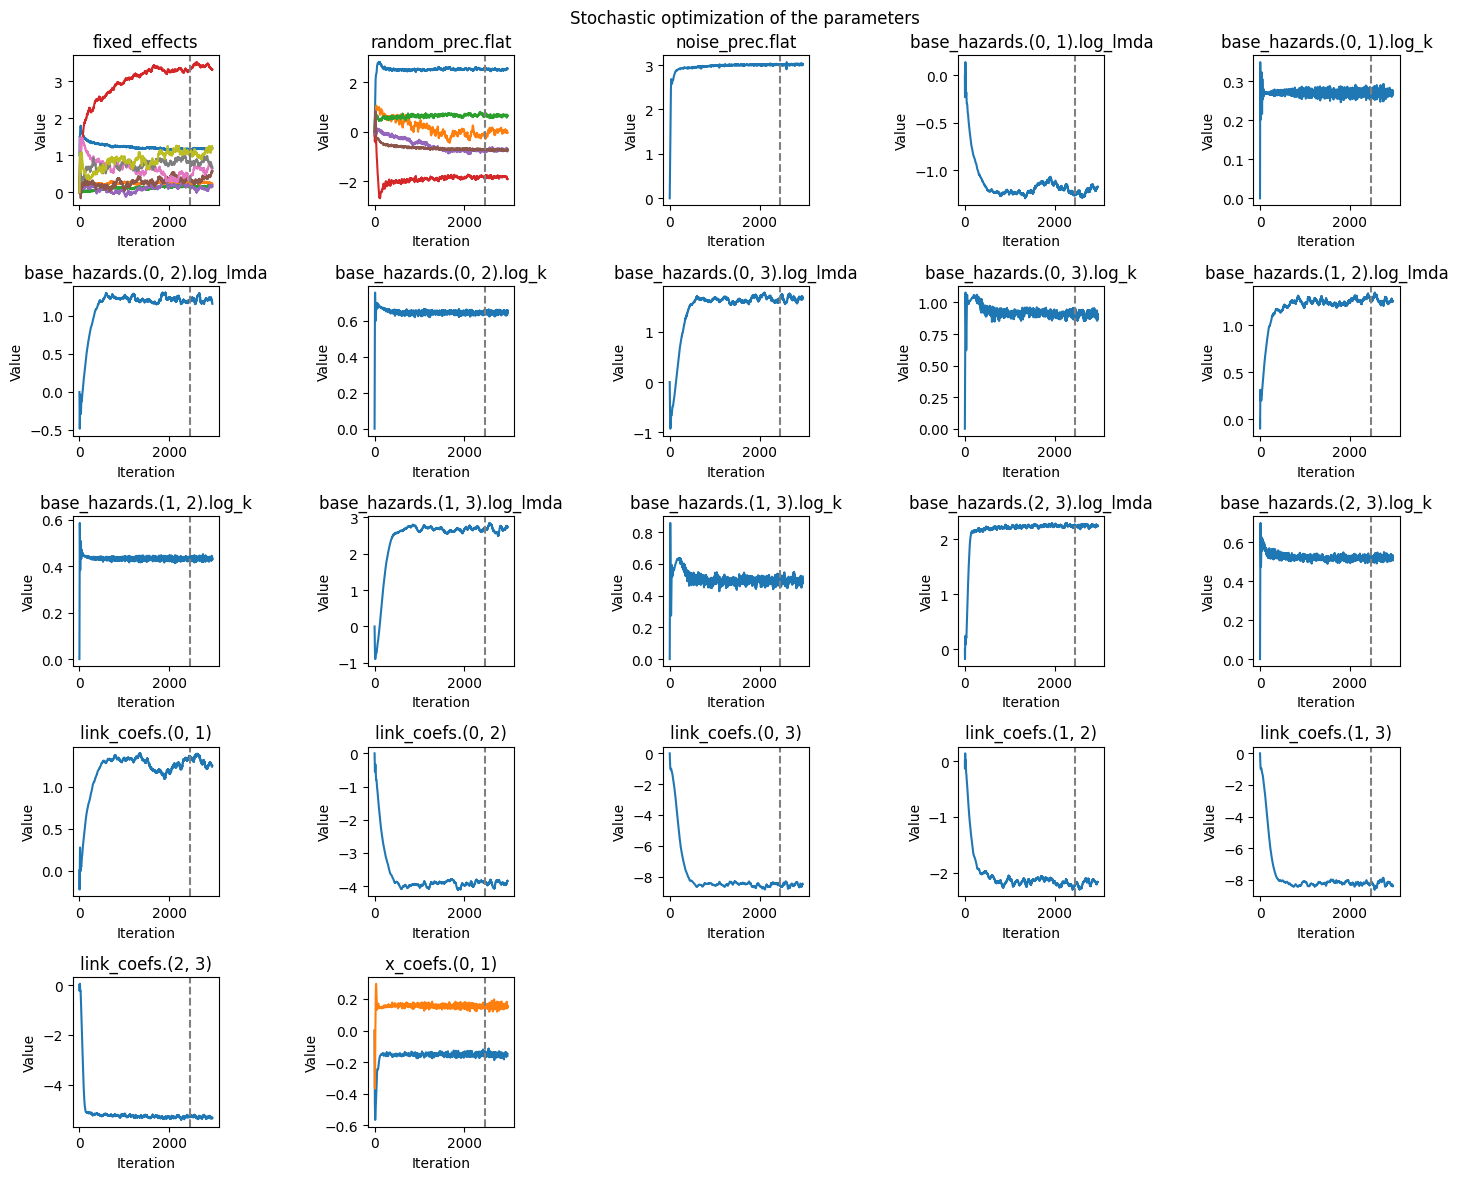

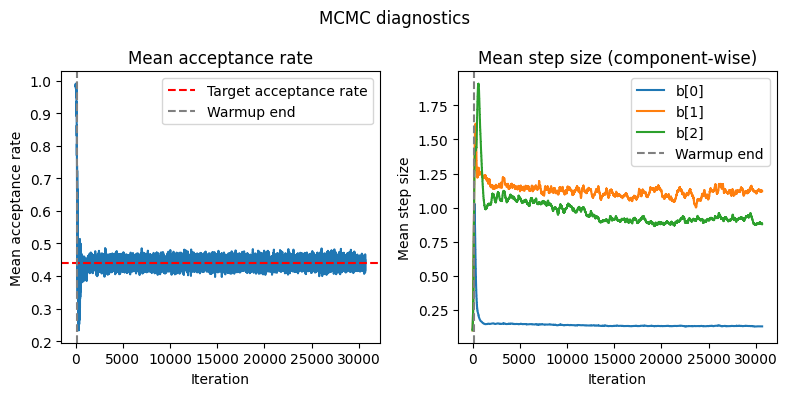

In [8]:
from jmstate.utils import plot_mcmc_diagnostics, plot_params_history

model.compute_summary().summary()

fig, axes = plot_params_history(model, figsize=(15, 12))

conv = len(model.params_history_) - model.window_size
for ax in axes:
    ax.axvline(x=conv, c="gray", linestyle="--")
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.savefig("../figures/paquid-optimization.pdf")
plt.show()

plot_mcmc_diagnostics(model)
plt.savefig("../figures/paquid-diagnostics.pdf")
plt.show()

In [9]:
from dataclasses import replace


def predict_cond(model: MultiStateJointModel, data_test: ModelData, cond_time: float):
    trajectories_cond = [
        [traj[0]] + [(t, s) for (t, s) in traj[1:] if t <= cond_time]
        for traj in data_test.trajectories
    ]
    c = torch.tensor([traj[-1][0] for traj in trajectories_cond])[:, None]

    y_trunc = data_test.y.clone()
    y_trunc[data_test.t > cond_time] = torch.nan

    data_test_cond = replace(
        data_test,
        y=y_trunc,
        trajectories=trajectories_cond,
        c=torch.maximum(c, cond_time),
    )
    return model.predict_trajectories(data_test_cond, c=data_test.c, n_samples=100)


def hier_probs(pred_trajectories: list[list[list[tuple[float, Any]]]], u: float):
    counts = torch.zeros(len(pred_trajectories[0]), 4)

    for trajectories in pred_trajectories:
        for i, trajectory in enumerate(trajectories):
            last_valid_state = trajectory[0][1]
            for t, s in reversed(trajectory):
                if t <= u:
                    last_valid_state = s
                    break

            counts[i][last_valid_state] += 1

    return counts / len(pred_trajectories)


def normalized_brier(pred_probs: torch.Tensor, real_states: torch.Tensor):
    bs_model = ((pred_probs - real_states) ** 2).mean()
    baseline = real_states.mean(dim=0)
    bs_baseline = ((baseline - real_states) ** 2).mean()
    return 1 - (bs_model / bs_baseline).item()


def accuracy(pred_probs: torch.Tensor, real_states: torch.Tensor):
    pred = pred_probs.argmax(dim=1)
    real = real_states.argmax(dim=1)
    return torch.mean((pred == real).float()).item()

In [10]:
from sklearn.model_selection import KFold

# Number of folds to use
K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42)

# Define landmark times on which to condition
cond_times = torch.linspace(0, data.c.max(), 5)[:-2]
us = torch.linspace(0, 4, 50)

BSS = torch.zeros(K, len(cond_times), len(us))
Acc = torch.zeros(K, len(cond_times), len(us))

torch.manual_seed(42)
for fold_idx, (train_idxs, test_idxs) in enumerate(kf.split(data)):
    data_train, data_test = data[train_idxs], data[test_idxs]

    params = init_params()
    optimizer = torch.optim.Adam(params.parameters(), lr=0.1)
    model = MultiStateJointModel(
        design,
        params,
        optimizer,
        max_iter=5000,
        window_size=500,
    ).fit(data_train)

    for i, cond_time in enumerate(cond_times):
        pred_trajectories = predict_cond(model, data_test, cond_time)
        mask = (data_test.c > cond_time).flatten()

        for j, u in enumerate(us):
            pred_probs = hier_probs(pred_trajectories, u)[mask]
            real_states = hier_probs([data_test.trajectories], u)[mask]
            BSS[fold_idx, i, j] = torch.tensor(
                normalized_brier(pred_probs, real_states)
            )
            Acc[fold_idx, i, j] = torch.tensor(accuracy(pred_probs, real_states))

Predicting trajectories: 100%|██████████| 20/20 [00:07<00:00,  2.62it/s]


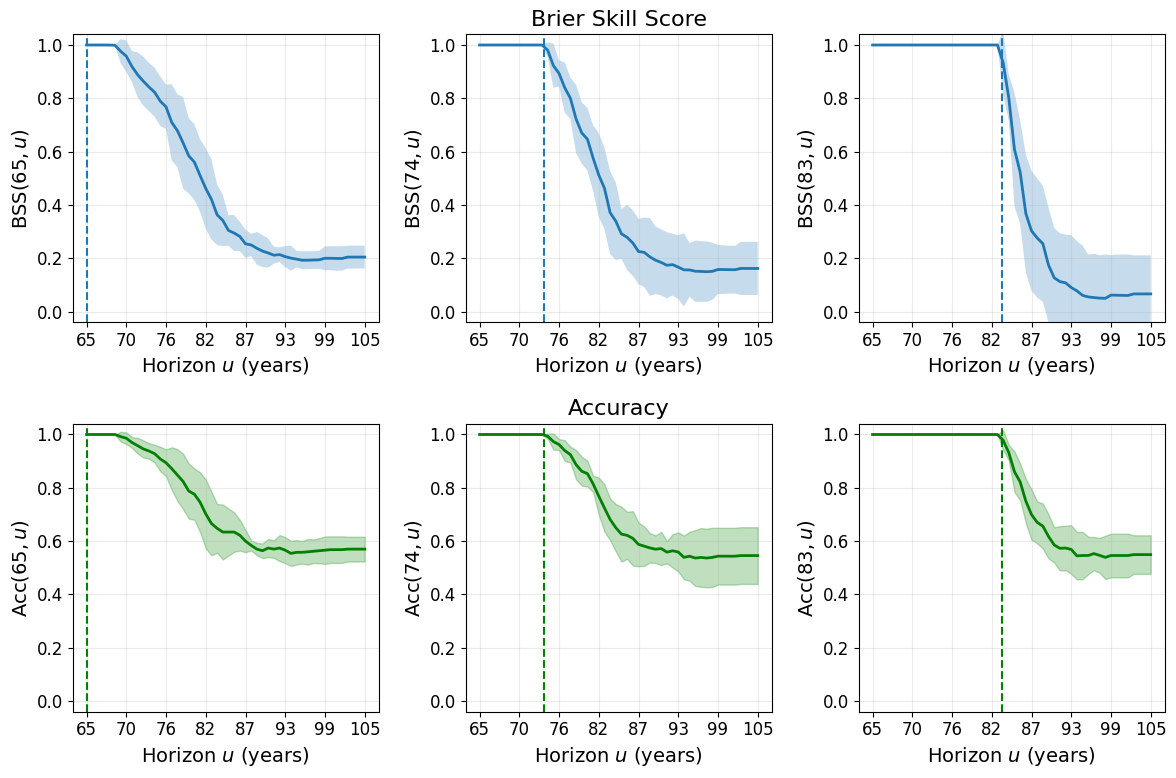

In [11]:
from scipy.stats import norm

# Get 95% quantile
q95 = norm.ppf(0.95)

with plt.rc_context(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

    age_ticks = [int(65 + 10 * u) for u in us[::7]]
    for i, cond_time in enumerate(cond_times):
        cond_age = int(65 + cond_time * 10)

        # Top
        ax = axes[0, i]
        BSS_mean = BSS[:, i].mean(dim=0)
        BSS_std = q95 * BSS[:, i].std(dim=0)
        ax.plot(us, BSS_mean, linewidth=2)
        ax.fill_between(us, BSS_mean - BSS_std, BSS_mean + BSS_std, alpha=0.25)
        ax.axvline(cond_time, linestyle="--")
        ax.set_ylabel(rf"$\mathrm{{BSS}}({cond_age}, u)$")
        ax.set_xlabel(r"Horizon $u$ (years)")
        ax.set_xticks(us[::7])
        ax.set_xticklabels(age_ticks)
        ax.grid(alpha=0.25)
        ax.set_ylim(-0.04, 1.04)

        # Bottom
        ax = axes[1, i]
        Acc_mean = Acc[:, i].mean(dim=0)
        Acc_std = q95 * Acc[:, i].std(dim=0)
        ax.plot(us, Acc_mean, linewidth=2, color="green")
        ax.fill_between(
            us, Acc_mean - Acc_std, Acc_mean + Acc_std, alpha=0.25, color="green"
        )
        ax.axvline(cond_time, linestyle="--", color="green")
        ax.set_ylabel(rf"$\mathrm{{Acc}}({cond_age}, u)$")
        ax.set_xlabel(r"Horizon $u$ (years)")
        ax.set_xticks(us[::7])
        ax.set_xticklabels(age_ticks)
        ax.grid(alpha=0.25)
        ax.set_ylim(-0.04, 1.04)

    axes[0, 1].set_title("Brier Skill Score")
    axes[1, 1].set_title("Accuracy")

    plt.tight_layout()
    plt.savefig("../figures/paquid-accuracy.pdf")
    plt.show()